In [1]:
from datasets import WM_811K
IMSIZE = (64,64)
ds = WM_811K(IMSIZE)

I0000 00:00:1778991704.241269  602178 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1778991720.164472  602178 cpu_allocator_impl.cc:82] Allocation of 210075648 exceeds 10% of free system memory.


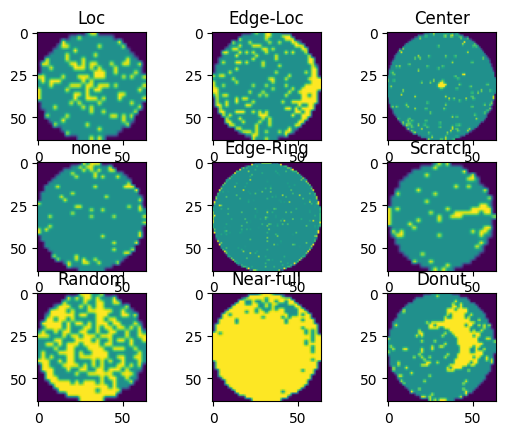

In [2]:
ds.preview()

In [3]:
import tensorflow as tf

BATCH_SIZE = 32

dataset = tf.data.Dataset.from_tensor_slices((ds.X, ds.labels))
train_ds, test_ds = tf.keras.utils.split_dataset(
    dataset, left_size=0.8, shuffle=True, seed=42)
train_ds, validation_ds = tf.keras.utils.split_dataset(
    train_ds, left_size=0.8, seed=42)

W0000 00:00:1778991757.792801  602178 cpu_allocator_impl.cc:82] Allocation of 210075648 exceeds 10% of free system memory.
W0000 00:00:1778991760.962733  602178 cpu_allocator_impl.cc:82] Allocation of 168067072 exceeds 10% of free system memory.
W0000 00:00:1778991762.141320  602178 cpu_allocator_impl.cc:82] Allocation of 42008576 exceeds 10% of free system memory.
W0000 00:00:1778991762.209790  602178 cpu_allocator_impl.cc:82] Allocation of 168067072 exceeds 10% of free system memory.


In [4]:
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMSIZE[0], IMSIZE[1], 1)),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(ds.label_names), activation='softmax'),
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723,945 (2.76 MB)

 Trainable params: 723,561 (2.76 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-7
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='../models/direct_classifier_cnn.keras', 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    x=train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.3928 - loss: 1.9174
Epoch 1: val_accuracy improved from None to 0.15887, saving model to best_wafer_cnn.keras

Epoch 1: finished saving model to best_wafer_cnn.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 66s 244ms/step - accuracy: 0.4834 - loss: 1.4897 - val_accuracy: 0.1589 - val_loss: 5.8096 - learning_rate: 0.0010
Epoch 2/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5995 - loss: 1.0914
Epoch 2: val_accuracy improved from 0.15887 to 0.31823, saving model to best_wafer_cnn.keras

Epoch 2: finished saving model to best_wafer_cnn.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 64s 247ms/step - accuracy: 0.6117 - loss: 1.0611 - val_accuracy: 0.3182 - val_loss: 2.1688 - learning_rate: 0.0010
Epoch 3/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.6570 - loss: 0.9240
Epoch 3: val_accuracy improved from 0.31823 to 0.59259, saving model to best_wafer_cnn.keras

Epoch 3: finished saving model to best_wafer_cnn.keras
257/

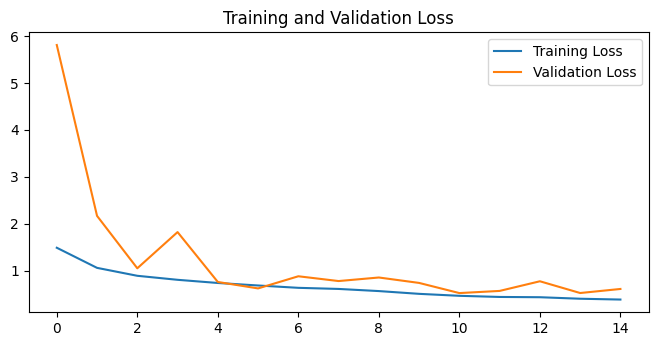

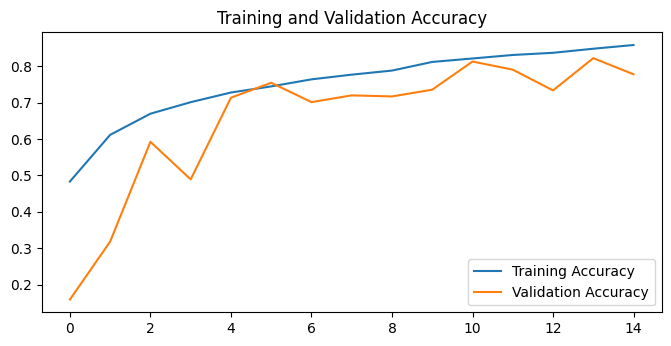

In [7]:
import matplotlib.pyplot as plt

# Training Loss
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Training Accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

In [8]:
model.evaluate(test_ds)

 1/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7500 - loss: 0.5632

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8237 - loss: 0.4896


[0.4895859956741333, 0.823712944984436]